![Machine Learning Pipeline for Credit Risk Analysis](Banner_ML.png)


# Loan Approval Decision-Making Through Machine Learning: A Credit Risk Analytics Approach


## Overview
This is a machine learning classification model that will help to enhance loan approval decision-making at FinTech Innovations. Using the CRISP-DM framework, the model analyzes historical applicant data to identify creditworthy borrowers while minimizing costly loan defaults. 


The final machine learning classification model demonstrates a strong performance in predicting loan approval decisions, effectively distinguishing between creditworthy and high-risk applicants. By optimizing evaluation metrics such as precision, recall, F1-score, and ROC-AUC, the model is designed to minimize costly false positives—approving applicants who are likely to default—while maintaining an acceptable approval rate for creditworthy borrowers. This cost-sensitive approach supports FinTech Innovations' business objective of reducing default-related losses (estimated at $50,000 per bad loan) while maximizing lending opportunities (worth approximately $8,000 per successful loan). As a decision-support tool, the model enables faster, more consistent, and data-driven loan approvals, improving operational efficiency and strengthening the company's overall credit risk management.


Every loan approval is a balance between opportunity and risk. Approving a loan to a creditworthy customer generates profit and strengthens customer relationships, while approving a loan to a high-risk borrower can result in significant financial losses. At FinTech Innovations, manual loan evaluations are becoming increasingly challenging as application volumes grow, making consistency, speed, and accuracy critical to maintaining profitability.

This project explores how machine learning can enhance the loan approval process by using historical applicant data to predict whether a loan should be approved or rejected. This model has been achieved by transforming raw data into actionable insights through data preparation, exploratory analysis, model development, and evaluation.The model is designed to prioritize minimizing high-risk approvals while supporting fair and informed lending decisions. 

## Business Understanding
### 1. The business context of FinTech Innovations' loan approval process.

#### 1.1 Current manual process and its limitations

FinTech Innovations currently relies on a manual loan approval process where loan officers review each applicant's financial information, such as income, employment status, credit history, existing debts, and other relevant factors, before deciding whether to approve or reject a loan application. While human expertise is valuable, this process has several limitations. It can be time-consuming, inconsistent across different loan officers, and susceptible to human bias and errors. As the number of loan applications increases, manual reviews become less efficient, leading to slower decisions and higher operational costs.

Machine learning can help by providing consistent, data-driven predictions that support loan officers or automate the initial screening process, improving both speed and accuracy.


#### 1.2 Key stakeholders and their needs

**Loan Officers:** Need fast, accurate, and consistent recommendations to support lending decisions.

**Risk Analytics Team:** Need reliable predictive model that accurately identifies risky applicants while minimizing costly mistakes.

**Banks' Management:** Need increased profitability, reduced default losses, and improved operational efficiency.

**Banks' Customers:** Require fair, transparent, and timely loan decisions.

**Regulatory and Compliance:** Ensure fair lending decisions that comply with financial regulations and avoid discriminatory practices.


#### 1.3 Implications of different types of model errors

**False Positive (Type I Error)**

The model predicts that an applicant is creditworthy (approve the loan) when they are actually high-risk and likely to default.

*Business Impact*

The company loses approximately $50,000 per defaulted loan.

Financial losses include unpaid principal, recovery costs, and legal expenses.

This is the most expensive type of error.


**False Negative (Type II Error)**

The model predicts that an applicant is high-risk (reject the loan) when they are actually creditworthy.

*Business Impact*

The company loses approximately $8,000 in profit from each rejected good customer.

Potential customers may also seek loans from competitors.

While costly, this error is significantly less expensive than approving a bad loan.

**Overall Business Implication**

Because approving a bad loan costs $50,000, while rejecting a good applicant costs only $8,000, the model will prioritize minimizing false positives, even if it means rejecting a few additional good applicants.

This business objective will influence:

- Model selection
- Evaluation metrics
- Probability threshold selection

#### 1.4 Classification or regression approach?

A *regression model* predicts a continuous value, such as the probability or risk score that an applicant will default. It can provide a detailed risk score whereby loan officers can use the score together with their judgment and can show flexible approval thresholds. 

However, a regression model will require the bank team to convert the risk scores into an approval decision, therefore not achieving the objective of automation as is required of an effective lending model.

A *classification model* on the other hand predicts whether a loan should be approved or rejected by automatically identifying a low risk and a high risk bank customer. This complete automation of the system directly supports the banks' needs as the model will produces immediate approval recommendations, it will be easy to deploy and will be simple for the bank staff to interpret.

This shows that the *appropriate model is a classification model* because the primary business objective is to determine whether a loan application should be approved or rejected. The target variable is naturally binary (e.g., approve/reject or default/non-default), making classification algorithms such as Logistic Regression, Decision Trees, Random Forests, or Gradient Boosting suitable choices.

Furthermore, the business has identified a much higher cost for approving bad loans ($50,000) than for rejecting good applicants ($8,000). Classification models allow decision thresholds to be adjusted to minimize these costly false positives, aligning the model with the company's financial objectives.



### 2. Modeling goals and success criteria:

The primary goal of this project is to develop a machine learning classification model that accurately predicts whether a loan application should be approved or rejected based on historical applicant data. The model will support loan officers by identifying high-risk applicants while minimizing costly loan defaults and improving the speed and consistency of lending decisions.

#### 2.1 Appropriate evaluation metrics based on business impact

**Precision (Primary Metric)**

Precision will check the proportion of applicants predicted as creditworthy who are actually creditworthy.This will help catch false positives and ensure that applicants approved by the model are more likely to repay their loans, thereby reducing financial losses.


**Recall**

Recall will evaluate the proportion of actual creditworthy applicants that are correctly identified by the model. A low recall would result in rejecting many good applicants, leading to lost business opportunities worth approximately $8,000 per missed loan. Recall metric will ensure that profitable customers are not unnecessarily denied credit.


**F1-Score**

Definition: The F1-score is the harmonic mean of precision and recall.

Reason for Selection:
Since both approving risky borrowers and rejecting good borrowers have financial consequences, the F1-score provides a balanced measure of model performance by considering both precision and recall.

**ROC-AUC**

ROC-AUC will measure the model's ability to distinguish between high-risk and low-risk applicants across different classification thresholds. This metric evaluates the model independently of a specific decision threshold, making it useful for comparing different classification algorithms before selecting the final model.


#### 2.2 Custom Business metric

The evaluation metrics above treat all prediction errors equally. However, in this scenario, approving a bad loan is more than six times as costly as rejecting a good applicant. Using a cost-based Business Metric will help to directly aligns model evaluation with the company's financial objectives by quantifying the expected business cost of prediction errors. 


**Business Cost Function**

Total Cost = (False Positives × $50,000) + (False Negatives × $8,000)

where:

False Positive (FP): A risky applicant is incorrectly approved.
False Negative (FN): A creditworthy applicant is incorrectly rejected.


#### 2.3 Baseline performance targets

To determine whether the model is suitable for deployment, the following performance targets will be established.

**Precision** ≥ 90% :  This will minimize costly approvals of high-risk applicants. 

**Recall**	≥ 80% :	This target will help identify most creditworthy applicants while maintaining profitability.

**F1-Score** ≥ 0.85 :	This will maintain a strong balance between precision and recall.

**ROC-AUC**	≥ 0.90 :	This performance target shows excellent discrimination between low- and high-risk applicants.

**Business Cost	Lower than the baseline model** will help to reduce the total financial impact of incorrect lending decisions.


## Data Understanding


### 3. Comprehensive exploratory data analysis:


In [189]:
# Imports
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

from scipy.stats import chi2_contingency
from sklearn.model_selection import (train_test_split, StratifiedKFold, cross_val_score, GridSearchCV)
from sklearn.pipeline import (Pipeline, FeatureUnion)
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (StandardScaler, OneHotEncoder, OrdinalEncoder, PolynomialFeatures, MinMaxScaler)
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score, roc_auc_score,
                               confusion_matrix, classification_report)

#### 3.1 Basic data characteristics

In [109]:
# EDA Code Here - Create New Cells As Needed

# Read the CSV file into a DataFrame
df = pd.read_csv("financial_loan_data.csv")
df.head()

,Age,AnnualIncome,CreditScore,EmploymentStatus,EducationLevel,Experience,LoanAmount,LoanDuration,MaritalStatus,NumberOfDependents,...,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,RiskScore
0,45,"$39,948.00",617,Employed,Master,22,13152,48,Married,2,...,3329.000000,0.724972,11,126928,0.199652,0.227590,419.805992,0.181077,0,49.0
1,38,"$39,709.00",628,Employed,Associate,15,26045,48,Single,1,...,3309.083333,0.935132,3,43609,0.207045,0.201077,794.054238,0.389852,0,52.0
2,47,"$40,724.00",570,Employed,Bachelor,26,17627,36,NaN,2,...,3393.666667,0.872241,6,5205,0.217627,0.212548,666.406688,0.462157,0,52.0
3,58,"$69,084.00",545,Employed,High School,34,37898,96,Single,1,...,5757.000000,0.896155,5,99452,0.300398,0.300911,1047.506980,0.313098,0,54.0
4,37,"$103,264.00",594,Employed,Associate,17,9184,36,Married,1,...,8605.333333,0.941369,5,227019,0.197184,0.175990,330.179140,0.070210,1,36.0


In [110]:
# Explore the dataset
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 35 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         20000 non-null  int64  
 1   AnnualIncome                20000 non-null  object 
 2   CreditScore                 20000 non-null  int64  
 3   EmploymentStatus            20000 non-null  object 
 4   EducationLevel              19099 non-null  object 
 5   Experience                  20000 non-null  int64  
 6   LoanAmount                  20000 non-null  int64  
 7   LoanDuration                20000 non-null  int64  
 8   MaritalStatus               18669 non-null  object 
 9   NumberOfDependents          20000 non-null  int64  
 10  HomeOwnershipStatus         20000 non-null  object 
 11  MonthlyDebtPayments         20000 non-null  int64  
 12  CreditCardUtilizationRate   20000 non-null  float64
 13  NumberOfOpenCreditLines     200

In [111]:
# Check the shape of the dataset
df.shape

(20000, 35)

In [112]:
df.describe()

,Age,CreditScore,Experience,LoanAmount,LoanDuration,NumberOfDependents,MonthlyDebtPayments,CreditCardUtilizationRate,NumberOfOpenCreditLines,NumberOfCreditInquiries,...,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,RiskScore
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,...,20000.000000,20000.000000,20000.000000,2.000000e+04,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,39.752600,571.612400,17.522750,24882.867800,54.057000,1.517300,454.292700,0.286381,3.023350,0.993000,...,4891.715521,0.799918,5.002650,7.229432e+04,0.239124,0.239110,911.607052,0.402182,0.239000,50.766780
std,11.622713,50.997358,11.316836,13427.421217,24.664857,1.386325,240.507609,0.159793,1.736161,0.986965,...,3296.771598,0.120665,2.236804,1.179200e+05,0.035509,0.042205,674.583473,0.338924,0.426483,7.778262
min,18.000000,343.000000,0.000000,3674.000000,12.000000,0.000000,50.000000,0.000974,0.000000,0.000000,...,1250.000000,0.259203,0.000000,1.000000e+03,0.130101,0.113310,97.030193,0.016043,0.000000,28.800000
25%,32.000000,540.000000,9.000000,15575.000000,36.000000,0.000000,286.000000,0.160794,2.000000,0.000000,...,2629.583333,0.727379,3.000000,8.734750e+03,0.213889,0.209142,493.763700,0.179693,0.000000,46.000000
50%,40.000000,578.000000,17.000000,21914.500000,48.000000,1.000000,402.000000,0.266673,3.000000,1.000000,...,4034.750000,0.820962,5.000000,3.285550e+04,0.236157,0.235390,728.511452,0.302711,0.000000,52.000000
75%,48.000000,609.000000,25.000000,30835.000000,72.000000,2.000000,564.000000,0.390634,4.000000,2.000000,...,6163.000000,0.892333,6.000000,8.882550e+04,0.261533,0.265532,1112.770759,0.509214,0.000000,56.000000
max,80.000000,712.000000,61.000000,184732.000000,120.000000,5.000000,2919.000000,0.917380,13.000000,7.000000,...,25000.000000,0.999433,16.000000,2.603208e+06,0.405029,0.446787,10892.629520,4.647657,1.000000,84.000000


In [113]:
# Check current data types of the columns
df.dtypes

Age                             int64
AnnualIncome                   object
CreditScore                     int64
EmploymentStatus               object
EducationLevel                 object
Experience                      int64
LoanAmount                      int64
LoanDuration                    int64
MaritalStatus                  object
NumberOfDependents              int64
HomeOwnershipStatus            object
MonthlyDebtPayments             int64
CreditCardUtilizationRate     float64
NumberOfOpenCreditLines         int64
NumberOfCreditInquiries         int64
DebtToIncomeRatio             float64
BankruptcyHistory              object
LoanPurpose                    object
PreviousLoanDefaults            int64
PaymentHistory                  int64
LengthOfCreditHistory           int64
SavingsAccountBalance         float64
CheckingAccountBalance          int64
TotalAssets                     int64
TotalLiabilities                int64
MonthlyIncome                 float64
UtilityBills

In [114]:
# Check for missing values
df.isnull().sum()

Age                              0
AnnualIncome                     0
CreditScore                      0
EmploymentStatus                 0
EducationLevel                 901
Experience                       0
LoanAmount                       0
LoanDuration                     0
MaritalStatus                 1331
NumberOfDependents               0
HomeOwnershipStatus              0
MonthlyDebtPayments              0
CreditCardUtilizationRate        0
NumberOfOpenCreditLines          0
NumberOfCreditInquiries          0
DebtToIncomeRatio                0
BankruptcyHistory                0
LoanPurpose                      0
PreviousLoanDefaults             0
PaymentHistory                   0
LengthOfCreditHistory            0
SavingsAccountBalance          572
CheckingAccountBalance           0
TotalAssets                      0
TotalLiabilities                 0
MonthlyIncome                    0
UtilityBillsPaymentHistory       0
JobTenure                        0
NetWorth            

The dataset contains 20,000 loan application records and 35 variables, providing a substantial amount of information for developing a machine learning model for loan approval prediction. 

The dataset comprises a mix of numerical and categorical features. Specifically, there are 18 integer variables, 10 float variables, and 7 categorical (object) variables. 

**Numerical features** include applicant characteristics such as Age, CreditScore, LoanAmount, LoanDuration, and MonthlyDebtPayments, while **categorical features** include variables such as EmploymentStatus, EducationLevel, MaritalStatus, HomeOwnershipStatus, BankruptcyHistory, and LoanPurpose. This combination of feature types suggests that both numerical scaling and categorical encoding will be required during data preprocessing.

The dataset contains two potential target variables: LoanApproved (an integer variable suitable for a classification task) and RiskScore (a continuous floating-point variable suitable for a regression task). Since the objective of this project is to automate loan approval decisions, LoanApproved will be selected as the target variable, while RiskScore may be retained as a potential explanatory feature or excluded if it represents information that would not be available at prediction time.

#### 3.2 Potential data quality issues and their implications

*Wrong Datatypes*

Based on the EDA, AnnualIncome appears to be stored as an object even though it should be a numerical variable, not a categorical one. It is being imported as an object because of the dollar symbol.

Storing the data in a wrong datatype may lead to incorrectly treating it as a categorical feature that could possibly interefere correlations and other data stories. 

Additionally, some columns are technically acceptable as int64, but if the original data included currency symbols or decimal amounts, they might be better stored as float64. These include: LoanAmount, MonthlyDebtPayments, CheckingAccountBalance, TotalAssets, TotalLiabilities, NetWorth.

It is necessary to convert all columns in their relevant datatypes that can make them usable for modeling and prediction. 


*Missing Values*
The dataset also exhibits some missing values. For example, EducationLevel contains 901 missing values, while MaritalStatus contains 1,331 missing values, and SavingsAccountBalance  has 572 missing values. The remaining variables shown in the summary have complete observations. These missing values will need to be investigated further and appropriately handled during the data preparation phase to ensure they do not adversely affect model performance.

In [115]:
# Correct Data Types
float_columns = [
    "LoanAmount",
    "MonthlyDebtPayments",
    "CheckingAccountBalance",
    "TotalAssets",
    "TotalLiabilities",
    "NetWorth"
]

# Clean AnnualIncome (remove $ and commas) and convert to float
df["AnnualIncome"] = (
    df["AnnualIncome"]
    .astype(str)
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
)

df["AnnualIncome"] = pd.to_numeric(df["AnnualIncome"], errors="coerce")

# Convert the remaining columns to float
df[float_columns] = df[float_columns].astype(float)

# Verify the changes
df.head()

,Age,AnnualIncome,CreditScore,EmploymentStatus,EducationLevel,Experience,LoanAmount,LoanDuration,MaritalStatus,NumberOfDependents,...,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,RiskScore
0,45,39948.0,617,Employed,Master,22,13152.0,48,Married,2,...,3329.000000,0.724972,11,126928.0,0.199652,0.227590,419.805992,0.181077,0,49.0
1,38,39709.0,628,Employed,Associate,15,26045.0,48,Single,1,...,3309.083333,0.935132,3,43609.0,0.207045,0.201077,794.054238,0.389852,0,52.0
2,47,40724.0,570,Employed,Bachelor,26,17627.0,36,NaN,2,...,3393.666667,0.872241,6,5205.0,0.217627,0.212548,666.406688,0.462157,0,52.0
3,58,69084.0,545,Employed,High School,34,37898.0,96,Single,1,...,5757.000000,0.896155,5,99452.0,0.300398,0.300911,1047.506980,0.313098,0,54.0
4,37,103264.0,594,Employed,Associate,17,9184.0,36,Married,1,...,8605.333333,0.941369,5,227019.0,0.197184,0.175990,330.179140,0.070210,1,36.0


In [116]:
# Check percentage of missing values
missing_summary = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": (df.isnull().sum() / len(df)) * 100
})

missing_summary = missing_summary[missing_summary["Missing Values"] > 0]
missing_summary.sort_values(by="Percentage", ascending=False)

,Missing Values,Percentage
MaritalStatus,1331,6.655
EducationLevel,901,4.505
SavingsAccountBalance,572,2.860


In [117]:
# Check the relationship between missing values and the selected target variable, LoanApproved
variables = ["EducationLevel", "MaritalStatus"]

results = []

for var in variables:
    summary = (
        df.groupby(df[var].isnull())["LoanApproved"]
        .agg(
            Total="count",
            Approved="sum",
            Approval_Rate="mean"
        )
        .reset_index()
    )

    summary["Variable"] = var
    summary["Missing"] = summary[var].map({False: "No", True: "Yes"})
    summary = summary.drop(columns=var)

    results.append(summary)

pd.concat(results, ignore_index=True)

,Total,Approved,Approval_Rate,Variable,Missing
0,19099,4780,0.250275,EducationLevel,No
1,901,0,0.000000,EducationLevel,Yes
2,18669,4454,0.238577,MaritalStatus,No
3,1331,326,0.244929,MaritalStatus,Yes


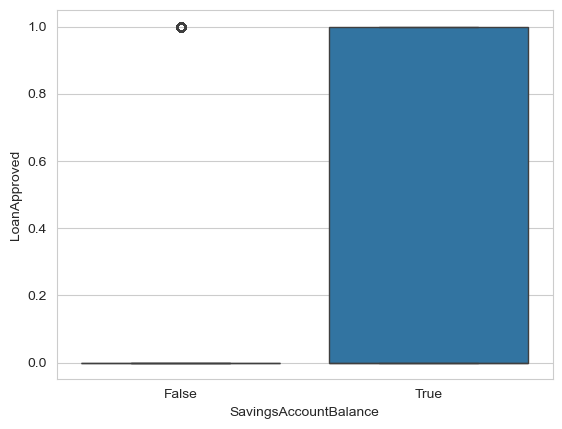

In [118]:
# Visualize the relationship between missing values and the selected target variable, LoanApproved

sns.boxplot(
    data=df,
    x=df["SavingsAccountBalance"].isnull(),
    y="LoanApproved"
)

plt.show()

#### Handling missing values

Approval rates are very different for rows with missing values in the columns **EducationLevel** and **SavingsAccountBalance** but seem almost similar for **MaritalStatus**. Therefore, it could be possible that the missing values may not be completely random for the two columns but random for MaritalStatus.

Therefore, to handle the missing values for MaritalStatus, I will replace values with the mode. 

For Education Level, I will create an "Unknown" category rather than imputing with the mode because the missing values may be informative.

For SavingsAccountBalance, I will create a missing indicator variable and then impute the missing values using the median.

In [119]:
# Replace missing values for MaritalStatus with the most frequent category
df["MaritalStatus"] = df["MaritalStatus"].fillna(
    df["MaritalStatus"].mode()[0]
)

df["MaritalStatus"].isnull().sum()

np.int64(0)

In [120]:
# Replace missing values  for EducationLevel with a new category "Unknown"
df["EducationLevel"] = df["EducationLevel"].fillna("Unknown")
df["EducationLevel"].isnull().sum()

np.int64(0)

In [121]:
#Handle Missing Values for SavingsAccountBalance: Create indicator for missing values
df["SavingsAccountBalance_Missing"] = (
    df["SavingsAccountBalance"]
    .isnull()
    .astype(int)
)

# Impute the missing values with the median.
df["SavingsAccountBalance"] = df["SavingsAccountBalance"].fillna(df["SavingsAccountBalance"].median())

In [122]:
# Check the dataset after handling missing values
df.isnull().sum()

Age                              0
AnnualIncome                     0
CreditScore                      0
EmploymentStatus                 0
EducationLevel                   0
Experience                       0
LoanAmount                       0
LoanDuration                     0
MaritalStatus                    0
NumberOfDependents               0
HomeOwnershipStatus              0
MonthlyDebtPayments              0
CreditCardUtilizationRate        0
NumberOfOpenCreditLines          0
NumberOfCreditInquiries          0
DebtToIncomeRatio                0
BankruptcyHistory                0
LoanPurpose                      0
PreviousLoanDefaults             0
PaymentHistory                   0
LengthOfCreditHistory            0
SavingsAccountBalance            0
CheckingAccountBalance           0
TotalAssets                      0
TotalLiabilities                 0
MonthlyIncome                    0
UtilityBillsPaymentHistory       0
JobTenure                        0
NetWorth            

In [123]:
# Check the shape of the dataset after handling missing values
df.shape

(20000, 36)

In [124]:
#Generates summary statistics for the numerical columns after handling missing values
df.describe()

,Age,AnnualIncome,CreditScore,Experience,LoanAmount,LoanDuration,NumberOfDependents,MonthlyDebtPayments,CreditCardUtilizationRate,NumberOfOpenCreditLines,...,UtilityBillsPaymentHistory,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,RiskScore,SavingsAccountBalance_Missing
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,...,20000.000000,20000.000000,2.000000e+04,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,39.752600,59161.473550,571.612400,17.522750,24882.867800,54.057000,1.517300,454.292700,0.286381,3.023350,...,0.799918,5.002650,7.229432e+04,0.239124,0.239110,911.607052,0.402182,0.239000,50.766780,0.028600
std,11.622713,40350.845168,50.997358,11.316836,13427.421217,24.664857,1.386325,240.507609,0.159793,1.736161,...,0.120665,2.236804,1.179200e+05,0.035509,0.042205,674.583473,0.338924,0.426483,7.778262,0.166684
min,18.000000,15000.000000,343.000000,0.000000,3674.000000,12.000000,0.000000,50.000000,0.000974,0.000000,...,0.259203,0.000000,1.000000e+03,0.130101,0.113310,97.030193,0.016043,0.000000,28.800000,0.000000
25%,32.000000,31679.000000,540.000000,9.000000,15575.000000,36.000000,0.000000,286.000000,0.160794,2.000000,...,0.727379,3.000000,8.734750e+03,0.213889,0.209142,493.763700,0.179693,0.000000,46.000000,0.000000
50%,40.000000,48566.000000,578.000000,17.000000,21914.500000,48.000000,1.000000,402.000000,0.266673,3.000000,...,0.820962,5.000000,3.285550e+04,0.236157,0.235390,728.511452,0.302711,0.000000,52.000000,0.000000
75%,48.000000,74391.000000,609.000000,25.000000,30835.000000,72.000000,2.000000,564.000000,0.390634,4.000000,...,0.892333,6.000000,8.882550e+04,0.261533,0.265532,1112.770759,0.509214,0.000000,56.000000,0.000000
max,80.000000,485341.000000,712.000000,61.000000,184732.000000,120.000000,5.000000,2919.000000,0.917380,13.000000,...,0.999433,16.000000,2.603208e+06,0.405029,0.446787,10892.629520,4.647657,1.000000,84.000000,1.000000


In [125]:
# #Generates summary statistics for the categorical columns
df.describe(include='object')

,EmploymentStatus,EducationLevel,MaritalStatus,HomeOwnershipStatus,BankruptcyHistory,LoanPurpose
count,20000,20000,20000,20000,20000,20000
unique,3,6,4,4,2,5
top,Employed,Bachelor,Married,Mortgage,No,Home
freq,17036,5804,10701,7939,18952,5925


#### 3.3 Distributions of all features and target variables

In [126]:
# Define the target variable and features
target = "LoanApproved"

# Define feature matrix and target vector
X = df.drop(columns=[target])
y = df[target]

X.columns


Index(['Age', 'AnnualIncome', 'CreditScore', 'EmploymentStatus',
       'EducationLevel', 'Experience', 'LoanAmount', 'LoanDuration',
       'MaritalStatus', 'NumberOfDependents', 'HomeOwnershipStatus',
       'MonthlyDebtPayments', 'CreditCardUtilizationRate',
       'NumberOfOpenCreditLines', 'NumberOfCreditInquiries',
       'DebtToIncomeRatio', 'BankruptcyHistory', 'LoanPurpose',
       'PreviousLoanDefaults', 'PaymentHistory', 'LengthOfCreditHistory',
       'SavingsAccountBalance', 'CheckingAccountBalance', 'TotalAssets',
       'TotalLiabilities', 'MonthlyIncome', 'UtilityBillsPaymentHistory',
       'JobTenure', 'NetWorth', 'BaseInterestRate', 'InterestRate',
       'MonthlyLoanPayment', 'TotalDebtToIncomeRatio', 'RiskScore',
       'SavingsAccountBalance_Missing'],
      dtype='object')

In [127]:
# Identify numerical and categorical features
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "category"]).columns.tolist()

print("Number of numerical features:", len(numeric_features))
print("Number of categorical features:", len(categorical_features))

Number of numerical features: 29
Number of categorical features: 6


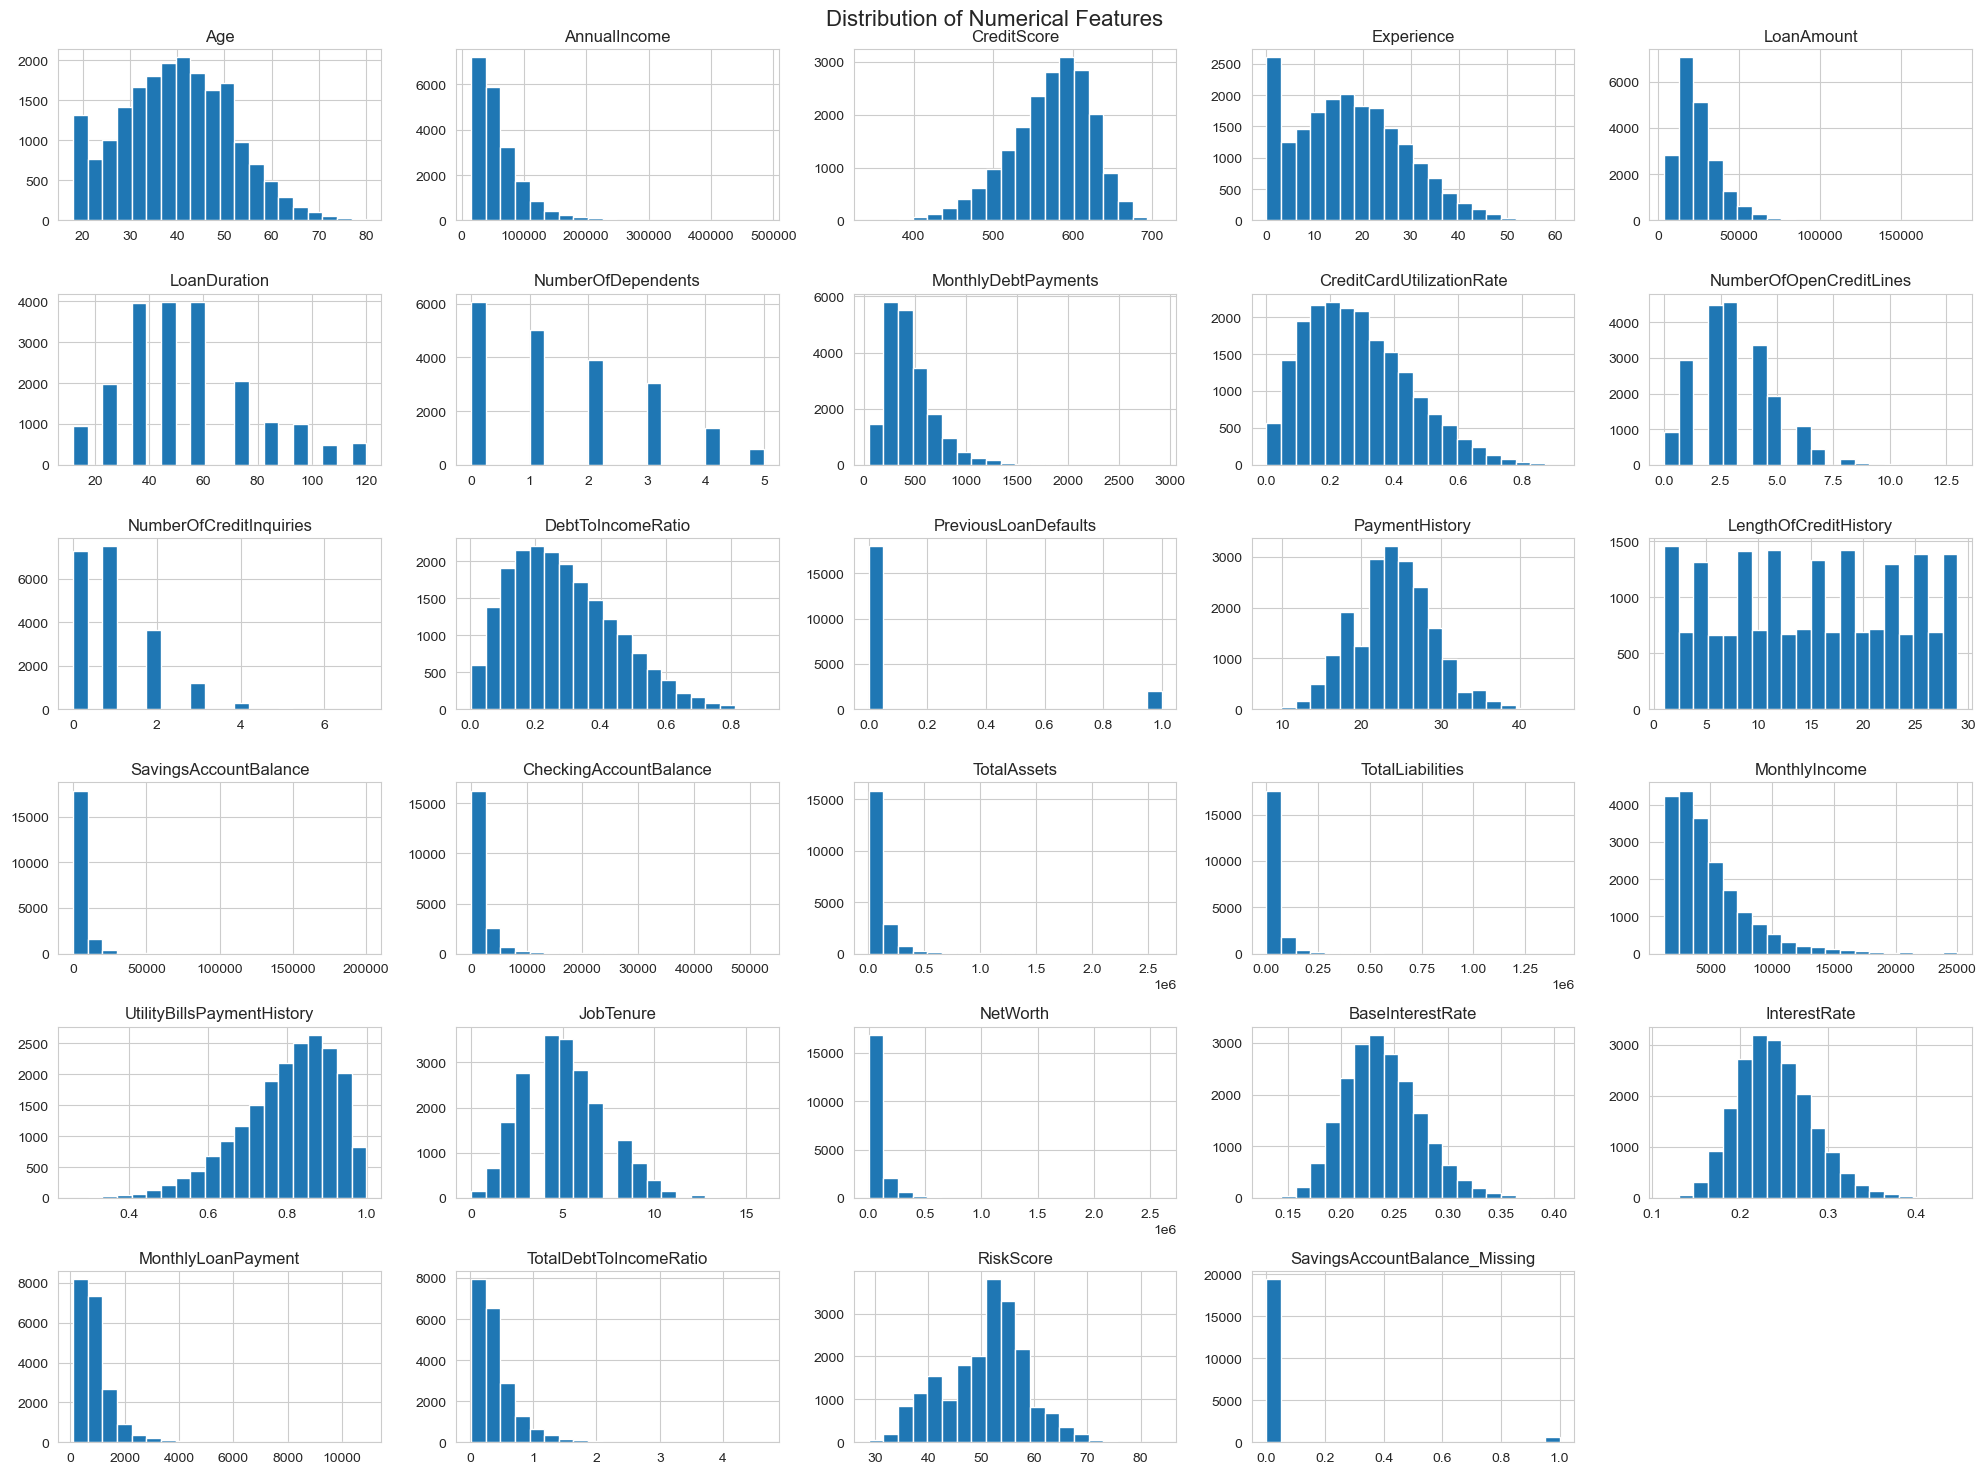

In [128]:
# Distribution of Numerical Features
X[numeric_features].hist(figsize=(20,15), bins=20)

plt.suptitle("Distribution of Numerical Features", fontsize=16)

plt.tight_layout()

plt.show()

From the histograms above, the numerical features exhibit a mix of approximately symmetric e.g CreditScore and InterestRate, right-skewed e.g DebtToIncomeRatio and discrete distributions e.g PreviousLoanDefaults. 

These distributions will require using median imputation for numerical variables because it is robust to skewness and outliers, and StandardScaler for Logistic Regression to reduce skewness in some financial features.


LoanApproved
0    15220
1     4780
Name: count, dtype: int64


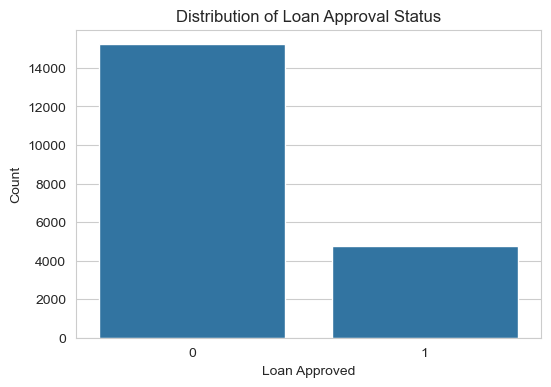

In [129]:
# Target Class Counts
print(y.value_counts())

# Distribution of the Target Variable
plt.figure(figsize=(6,4))

sns.countplot(x=y)

plt.title("Distribution of Loan Approval Status")
plt.xlabel("Loan Approved")
plt.ylabel("Count")

plt.show()

The target variable LoanApproved is imbalanced, with considerably more rejected loan applications than approved ones. Out of the 20,000 loan applications in the dataset:

15,220 applications (76.1%) were rejected (LoanApproved = 0).

4,780 applications (23.9%) were approved (LoanApproved = 1).

This imbalance suggests that classification models may be biased toward predicting the majority class (loan rejection). Consequently, model evaluation will emphasize metrics beyond accuracy, such as precision, recall, F1-score, and ROC-AUC, and class imbalance handling techniques may be explored during the modeling phase.

#### 3.4 Relationships between features

In [130]:
# Correlation Matrix for Numerical Features
corr_matrix = X[numeric_features].corr()

corr_matrix

,Age,AnnualIncome,CreditScore,Experience,LoanAmount,LoanDuration,NumberOfDependents,MonthlyDebtPayments,CreditCardUtilizationRate,NumberOfOpenCreditLines,...,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,RiskScore,SavingsAccountBalance_Missing
Age,1.000000,0.144774,0.323243,0.982980,-0.007492,-0.006992,-0.000287,0.015685,-0.001394,-0.001069,...,0.144634,-0.005601,-0.000773,0.014061,-0.238995,-0.202702,-0.021380,-0.111800,-0.164304,-0.001251
AnnualIncome,0.144774,1.000000,0.104045,0.145999,-0.004116,0.002972,-0.001244,-0.001082,-0.007935,-0.008175,...,0.989911,-0.012351,-0.000610,-0.004358,-0.074549,-0.063832,-0.004304,-0.532033,-0.483289,-0.000881
CreditScore,0.323243,0.104045,1.000000,0.327664,-0.010834,-0.000762,-0.014453,0.011153,-0.009650,-0.008780,...,0.104796,-0.006838,0.008069,0.001951,-0.722619,-0.598844,-0.063932,-0.115363,-0.240198,0.015381
Experience,0.982980,0.145999,0.327664,1.000000,-0.007921,-0.007924,0.000136,0.018629,-0.001751,-0.002143,...,0.145950,-0.006603,-0.000762,0.015049,-0.242871,-0.206252,-0.021691,-0.112825,-0.166496,0.000185
LoanAmount,-0.007492,-0.004116,-0.010834,-0.007921,1.000000,-0.000436,-0.007005,0.021103,0.000806,0.000769,...,-0.005407,-0.012107,0.005364,-0.003679,0.385663,0.322824,0.780828,0.457175,0.137981,0.009709
LoanDuration,-0.006992,0.002972,-0.000762,-0.007924,-0.000436,1.000000,-0.001301,0.000068,-0.006160,0.001489,...,0.003067,-0.010105,0.003635,-0.008779,0.579215,0.487994,-0.385495,-0.213984,0.054550,-0.000251
NumberOfDependents,-0.000287,-0.001244,-0.014453,0.000136,-0.007005,-0.001301,1.000000,-0.002396,0.011544,0.006033,...,-0.000414,0.008735,0.010910,-0.008423,0.006977,0.006749,-0.001390,-0.000358,0.001686,-0.000194
MonthlyDebtPayments,0.015685,-0.001082,0.011153,0.018629,0.021103,0.000068,-0.002396,1.000000,0.005420,0.006280,...,-0.000356,0.001638,0.005863,0.004430,0.000010,0.003895,0.018021,0.219453,0.036938,0.002060
CreditCardUtilizationRate,-0.001394,-0.007935,-0.009650,-0.001751,0.000806,-0.006160,0.011544,0.005420,1.000000,0.001491,...,-0.009381,0.013040,-0.006979,-0.003506,0.003668,0.001030,0.004366,0.010490,0.108758,-0.000673
NumberOfOpenCreditLines,-0.001069,-0.008175,-0.008780,-0.002143,0.000769,0.001489,0.006033,0.006280,0.001491,1.000000,...,-0.008050,-0.010497,0.007298,-0.002013,0.007457,0.008090,-0.005058,0.003471,0.007762,-0.007491


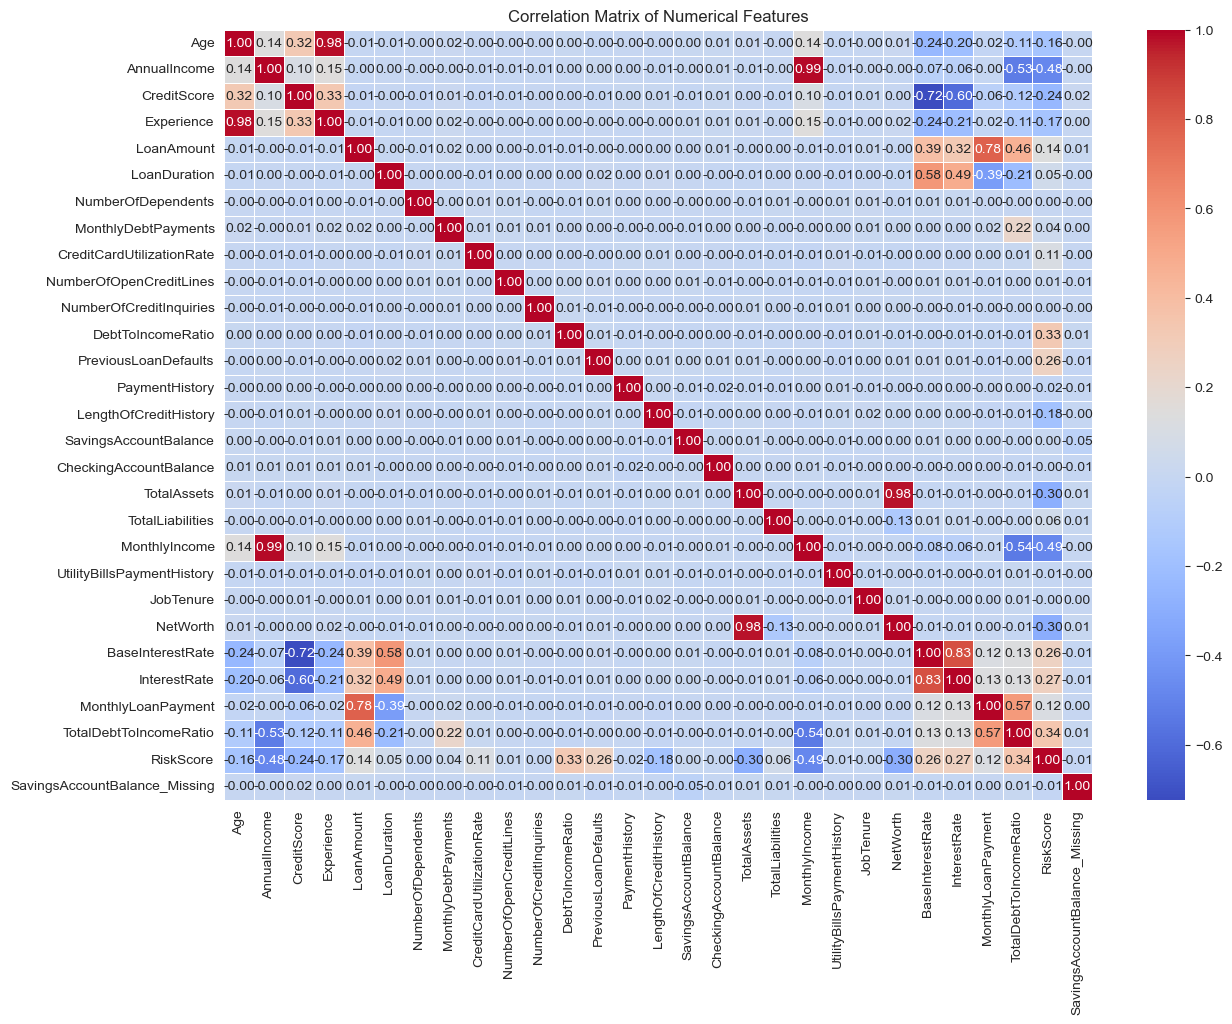

In [131]:
# Heatmap for correlation matrix of numerical features
plt.figure(figsize=(14,10))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Matrix of Numerical Features")

plt.show()

**Correlation Analysis of Numerical Features**

The correlation heatmap above shows a comprehensive overview of the linear relationships among the numerical features in the loan dataset. Overall, the majority of variables exhibit weak correlations, with coefficients close to zero, indicating that most features capture different aspects of an applicant's financial profile. This is a positive finding for predictive modeling, as it suggests that the dataset contains diverse and complementary information with minimal multicollinearity among most variables.

Despite the generally weak relationships, several feature pairs demonstrate strong positive correlations. The strongest correlation is observed between Age and Experience (r = 0.98), indicating that older applicants tend to have more years of work experience. Similarly, TotalAssets and NetWorth (r = 0.98) are almost perfectly correlated, reflecting the intuitive relationship that applicants with greater assets generally possess higher net worth. Another strong positive relationship exists between BaseInterestRate and InterestRate (r = 0.83), suggesting that the final interest rate offered to borrowers is largely determined by the institution's base lending rate. In addition, LoanAmount and MonthlyLoanPayment (r = 0.78) are strongly correlated, which is expected since larger loans typically result in higher monthly repayment amounts.

The heatmap also reveals several moderate positive correlations that align with normal lending practices. For example, LoanDuration is moderately correlated with both BaseInterestRate (r = 0.58) and InterestRate (r = 0.49), indicating that longer loan repayment periods are generally associated with higher borrowing costs. Likewise, MonthlyLoanPayment and TotalDebtToIncomeRatio (r = 0.57) exhibit a moderate positive relationship, suggesting that higher monthly loan obligations contribute to an applicant's overall debt burden.

Several meaningful negative correlations are also evident. The strongest negative relationship is observed between CreditScore and BaseInterestRate (r = –0.72), followed by CreditScore and InterestRate (r = –0.60). These findings indicate that applicants with stronger credit scores tend to receive lower interest rates, which is consistent with standard lending practices where financially reliable borrowers are rewarded with more favorable loan terms.

With respect to the RiskScore variable, moderate positive correlations are observed with TotalDebtToIncomeRatio (r = 0.34), DebtToIncomeRatio (r = 0.33), InterestRate (r = 0.27), BaseInterestRate (r = 0.26), and PreviousLoanDefaults (r = 0.26). These relationships suggest that applicants carrying higher debt obligations, facing higher borrowing costs, or having a history of loan defaults are more likely to be assigned higher risk scores. Conversely, MonthlyIncome (r = –0.49), NetWorth (r = –0.30), and TotalAssets (r = –0.30) are negatively correlated with RiskScore, indicating that applicants with stronger financial resources generally present lower credit risk.

In [132]:
# Correlation of numerical features with the target
target_corr = df[numeric_features + [target]].corr()[target]

# Sort from strongest to weakest
target_corr.sort_values(ascending=False)

LoanApproved                     1.000000
MonthlyIncome                    0.604101
AnnualIncome                     0.597900
NetWorth                         0.187892
TotalAssets                      0.184011
CreditScore                      0.142000
Age                              0.141029
Experience                       0.140755
LengthOfCreditHistory            0.105949
PaymentHistory                   0.030804
SavingsAccountBalance_Missing    0.010053
JobTenure                        0.004997
UtilityBillsPaymentHistory       0.003303
NumberOfDependents               0.001717
CheckingAccountBalance           0.000660
DebtToIncomeRatio                0.000034
SavingsAccountBalance           -0.000755
NumberOfOpenCreditLines         -0.004769
NumberOfCreditInquiries         -0.005885
CreditCardUtilizationRate       -0.010466
TotalLiabilities                -0.029434
PreviousLoanDefaults            -0.065343
MonthlyDebtPayments             -0.070415
LoanDuration                    -0

**The Correlation between Target variable "LoanApproved" and numerical features**

The correlation analysis shows that MonthlyIncome and AnnualIncome has the strongest positive relationship with loan approval (r = 0.604) and (r = 0.598) respectively. This relationship confirms that applicants with higher incomes are more likely to be approved. Other variables, including NetWorth, TotalAssets, CreditScore, Age, and Experience, have weak positive correlations, suggesting they also contribute positively to approval decisions. In contrast, BaseInterestRate, LoanAmount, and MonthlyLoanPayment have the strongest negative correlations, implying that applicants requesting larger loans or facing higher interest rates are less likely to be approved. Overall, most numerical features exhibit weak individual correlations with the target, indicating that loan approval is influenced by a combination of factors rather than a single variable.

In [133]:
# Correlation Pairs amongst numerical features
corr_pairs = (
    corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))  # Remove duplicate pairs and self-correlations
    .stack()
    .sort_values(ascending=False)
)
corr_pairs.head(20)

AnnualIncome            MonthlyIncome             0.989911
Age                     Experience                0.982980
TotalAssets             NetWorth                  0.978997
BaseInterestRate        InterestRate              0.834557
LoanAmount              MonthlyLoanPayment        0.780828
LoanDuration            BaseInterestRate          0.579215
MonthlyLoanPayment      TotalDebtToIncomeRatio    0.567842
LoanDuration            InterestRate              0.487994
LoanAmount              TotalDebtToIncomeRatio    0.457175
                        BaseInterestRate          0.385663
TotalDebtToIncomeRatio  RiskScore                 0.342643
CreditScore             Experience                0.327664
DebtToIncomeRatio       RiskScore                 0.326500
Age                     CreditScore               0.323243
LoanAmount              InterestRate              0.322824
InterestRate            RiskScore                 0.268203
PreviousLoanDefaults    RiskScore                 0.2586

In [134]:
corr_pairs.tail()

MonthlyIncome  RiskScore                -0.487039
AnnualIncome   TotalDebtToIncomeRatio   -0.532033
MonthlyIncome  TotalDebtToIncomeRatio   -0.538314
CreditScore    InterestRate             -0.598844
               BaseInterestRate         -0.722619
dtype: float64

**Correlation Pairs amongst numerical features**

The correlation analysis shows that most numerical features have weak relationships with each other, meaning they provide unique information for predicting loan approval. However, a few feature pairs, such as **Annual and Monthly Incomes** **Age and Experience**, **TotalAssets and NetWorth**, **BaseInterestRate and InterestRate**, and **LoanAmount and MonthlyLoanPayment**, are highly correlated because they measure similar financial or personal characteristics. 

Strong negative correlations, such as **CreditScore with BaseInterestRate**, indicate that applicants with better credit scores generally receive lower interest rates. Identifying these relationships is important because it helps detect redundant features, reduces multicollinearity, and supports better feature selection, ultimately leading to a more accurate and interpretable machine learning model.

In [135]:
# Cramer's V statistic for categorical-categorical association
def cramers_v(x, y):
    """
    Computes Cramér's V statistic for categorical-categorical association.
    """
    contingency_table = pd.crosstab(x, y)

    chi2 = chi2_contingency(contingency_table)[0]
    n = contingency_table.sum().sum()

    r, k = contingency_table.shape

    return np.sqrt(chi2 / (n * (min(r, k) - 1)))

# Correlation Matrix Categorical Features using Cramér's V
categorical_df = df[categorical_features]

cramers_matrix = pd.DataFrame(
    np.zeros((len(categorical_features), len(categorical_features))),
    index=categorical_features,
    columns=categorical_features
)

for col1 in categorical_features:
    for col2 in categorical_features:
        cramers_matrix.loc[col1, col2] = cramers_v(
            categorical_df[col1],
            categorical_df[col2]
        )

cramers_matrix

,EmploymentStatus,EducationLevel,MaritalStatus,HomeOwnershipStatus,BankruptcyHistory,LoanPurpose
EmploymentStatus,1.000000,0.067976,0.015365,0.006657,0.009174,0.017422
EducationLevel,0.067976,1.000000,0.011846,0.010211,0.016411,0.013150
MaritalStatus,0.015365,0.011846,1.000000,0.017627,0.016702,0.014348
HomeOwnershipStatus,0.006657,0.010211,0.017627,1.000000,0.008094,0.014900
BankruptcyHistory,0.009174,0.016411,0.016702,0.008094,0.999497,0.017035
LoanPurpose,0.017422,0.013150,0.014348,0.014900,0.017035,1.000000


In [136]:
# Perform the Chi-Square Test for All Categorical Features

results = []

for feature in categorical_features:

    # Create contingency table
    contingency_table = pd.crosstab(df[feature], df["LoanApproved"])

    # Chi-square test
    chi2, p, dof, expected = chi2_contingency(contingency_table)

    results.append({
        "Feature": feature,
        "Chi-Square": chi2,
        "Degrees of Freedom": dof,
        "P-value": p
    })

# Convert to DataFrame
chi_square_results = pd.DataFrame(results)

# Sort by p-value
chi_square_results = chi_square_results.sort_values("P-value")

chi_square_results

,Feature,Chi-Square,Degrees of Freedom,P-value
1,EducationLevel,1068.927568,5,7.157929e-229
4,BankruptcyHistory,99.370892,1,2.093774e-23
0,EmploymentStatus,38.506520,2,4.349261e-09
3,HomeOwnershipStatus,26.328828,3,8.138932e-06
5,LoanPurpose,6.695746,4,1.528671e-01
2,MaritalStatus,0.974536,3,8.074131e-01


**Chi-Square Test for All Categorical Features**
The Chi-Square test results indicate that EducationLevel, BankruptcyHistory, EmploymentStatus, and HomeOwnershipStatus have a statistically significant association with loan approval, as their p-values are well below the 0.05 significance level. Among these, EducationLevel shows the strongest association with loan approval, followed by BankruptcyHistory. In contrast, LoanPurpose (p = 0.153) and MaritalStatus (p = 0.807) are not significantly associated with loan approval, suggesting that these variables contribute little to distinguishing between approved and rejected loan applications. These findings indicate that the significant categorical features are likely to be more valuable predictors in the loan approval model, while the non-significant features may have limited predictive value.

### 4. Feature understanding:

#### 4.1 Feature Categories

Most of the variables are numerical, including income, credit score, loan amount, debt ratios, and account balances, which are useful for measuring an applicant's financial position and credit risk. 

The categorical features, such as employment status, marital status, home ownership status, bankruptcy history, and loan purpose, represent different applicant groups without any natural order. EducationLevel is the only ordinal feature because its categories follow a logical progression (e.g., High School, Bachelor's, Master's, PhD). 

I will define feature categories into numerical, binary, the norminal and ordinal features to ensure that the pre-processing technique applied is specific to the category of data. 

In [137]:
# Feature Selection: Drop potential RiskScore 
X = df.drop(columns=[target, "RiskScore"])
print(X.columns)

Index(['Age', 'AnnualIncome', 'CreditScore', 'EmploymentStatus',
       'EducationLevel', 'Experience', 'LoanAmount', 'LoanDuration',
       'MaritalStatus', 'NumberOfDependents', 'HomeOwnershipStatus',
       'MonthlyDebtPayments', 'CreditCardUtilizationRate',
       'NumberOfOpenCreditLines', 'NumberOfCreditInquiries',
       'DebtToIncomeRatio', 'BankruptcyHistory', 'LoanPurpose',
       'PreviousLoanDefaults', 'PaymentHistory', 'LengthOfCreditHistory',
       'SavingsAccountBalance', 'CheckingAccountBalance', 'TotalAssets',
       'TotalLiabilities', 'MonthlyIncome', 'UtilityBillsPaymentHistory',
       'JobTenure', 'NetWorth', 'BaseInterestRate', 'InterestRate',
       'MonthlyLoanPayment', 'TotalDebtToIncomeRatio',
       'SavingsAccountBalance_Missing'],
      dtype='object')


In [138]:
binary_features = [
    col for col in X.columns
    if df[col].dropna().nunique() == 2
]

binary_features

['BankruptcyHistory', 'PreviousLoanDefaults', 'SavingsAccountBalance_Missing']

In [139]:
numerical_features = X.drop(columns=binary_features).select_dtypes(include=["int64", "float64"]).columns.tolist()

numerical_features

['Age',
 'AnnualIncome',
 'CreditScore',
 'Experience',
 'LoanAmount',
 'LoanDuration',
 'NumberOfDependents',
 'MonthlyDebtPayments',
 'CreditCardUtilizationRate',
 'NumberOfOpenCreditLines',
 'NumberOfCreditInquiries',
 'DebtToIncomeRatio',
 'PaymentHistory',
 'LengthOfCreditHistory',
 'SavingsAccountBalance',
 'CheckingAccountBalance',
 'TotalAssets',
 'TotalLiabilities',
 'MonthlyIncome',
 'UtilityBillsPaymentHistory',
 'JobTenure',
 'NetWorth',
 'BaseInterestRate',
 'InterestRate',
 'MonthlyLoanPayment',
 'TotalDebtToIncomeRatio']

In [140]:
ordinal_features = [
    'EducationLevel'
]

ordinal_features

['EducationLevel']

In [141]:
categorical_features = X.drop(columns=numerical_features + binary_features + ordinal_features).select_dtypes(include=["object", "category"]).columns.tolist()
categorical_features

['EmploymentStatus', 'MaritalStatus', 'HomeOwnershipStatus', 'LoanPurpose']

#### 4.2 Features requiring special preprocessing  

Numerical features should be checked for outliers and scaled where appropriate. Nominal categorical features require one-hot encoding to convert them into numerical form. The ordinal feature should be ordinal encoded to preserve its natural ranking. 

Additionally, the engineered feature SavingsAccountBalance_Missingf should be retained as a binary indicator because it captures potentially useful information about missing values. 

Finally, RiskScore should be excluded from the predictor variables since it represents an alternative prediction target and including it would lead to data leakage, resulting in overfitting. 


### 4.3 Missing value patterns and their potential meanings

Section 3.2 on data issues and implications explains the distribution of missing values and their potential warnings.

### 4.4 Potential feature engineering opportunities
Highly correlated pairs helped us reveal that some variables measure very similar concepts. For example:

- AnnualIncome and MonthlyIncome both measure income

- Age and Experience both reflect an applicant's career stage 

- TotalAssets and NetWorth both describe financial wealth

- BaseInterestRate and InterestRate are closely related loan pricing variable

- LoanAmount and MonthlyLoanPayment both represent the size and cost of the loan

These relationships identify potential redundancy and multicollinearity. They however present opportunities for feature engineering by creating ratio or difference-based features that capture more meaningful business insights, such as repayment burden or career maturity.

Existing financial variables can be combined to create more informative indicators, such as Loan-to-Income Ratio (LoanAmount ÷ AnnualIncome) to measure loan affordability, Debt Service Ratio (MonthlyLoanPayment ÷ MonthlyIncome) to assess repayment capacity, and Asset-to-Liability Ratio (TotalAssets ÷ TotalLiabilities) to evaluate financial stability. 

Interaction features, such as combining CreditScore with BankruptcyHistory or EmploymentStatus with JobTenure, may better capture an applicant's creditworthiness than either variable alone. Additionally, the previously created SavingsAccountBalance_Missing indicator should be retained, as the absence of savings information may itself provide useful predictive information. These engineered features can help the model capture more meaningful financial relationships, leading to more accurate loan approval decisions.

## Data Preparation

### 5. Preprocessing:

#### 5.1 Preprocessing strategy:

**i. Data Type Correction**

The first step was to ensure that all variables have the correct data types. Financial variables such as AnnualIncome, LoanAmount, MonthlyDebtPayments, CheckingAccountBalance, TotalAssets, TotalLiabilities, and NetWorth should be converted to numerical format after removing currency symbols or formatting characters. Correct data types are essential for accurate statistical analysis and model training. Thos has been done in section 3.2


**ii. Missing Value Treatment**

Missing values have been handled according to their relationship with the target variable.

The values for EducationLevel have been replaced with "Unknown" as it appeared informative. 

MaritalStatus missing values were imputed using mode as the data appeared to be random, while SavingsAccountBalance was imputed using median on the missing indicator because it seemed to be informative too.


**iii. Feature Selection**

The target variable is LoanApproved, while RiskScore will be excluded from the predictor variables because it represents an alternative prediction target.


**iv. Feature Categorization**

Features has been grouped according to their type to determine the appropriate preprocessing technique.

- Numerical features: Financial measures, credit metrics, and applicant characteristics.

- Nominal categorical features: EmploymentStatus, MaritalStatus, HomeOwnershipStatus, BankruptcyHistory, LoanPurpose.

-Ordinal feature: EducationLevel.


**v. Encoding Categorical Variables**

Different encoding methods will be applied depending on the feature type, that is One-hot encoding for nominal features, and Ordinal Encoding for ordinal feature.


**vi. Scale Numerical Features**

Numerical variables will be standardized using StandardScaler when training algorithms such as Logistic Regression because these models are sensitive to differences in feature scales. 

Scaling will ensure that variables measured in different units, such as annual income, loan amount, and credit score, contribute fairly during model training. 

If tree-based models are later evaluated, scaling will not affect their performance but maintaining a consistent preprocessing pipeline will simplify model comparison.

**vii. Feature Engineering**

Additional features will be created to enhance the representation of an applicant's financial capacity and repayment ability. Features such as Loan-to-Income Ratio, which measures loan affordability, the Debt Service Ratio, which reflects the proportion of income required for monthly repayments, and the Asset-to-Liability Ratio, which indicates financial stability. These engineered features align more closely with how loan officers evaluate applicants and may improve the model's ability to identify risky borrowers

**viii. Check and workout redundancy of features**

Highly correlated variables such as AnnualIncome and MonthlyIncome, Age and Experience, LoanAmount and MonthlyLoanPayment, and TotalAssets and NetWorth will be reviewed for redundancy. Removing one from each pair makes the model simpler and improves interpretability.

Redundant variables may introduce multicollinearity and reduce model interpretability. Correlation analysis and Variance Inflation Factor (VIF) can be used to determine whether some variables should be combined, transformed, or removed. Tree-based models are less sensitive to multicollinearity.

**ix. Split the data into train and test sets**

Since the dataset is imbalanced, with substantially more rejected than approved loans, the data will be split using stratified sampling. This ensures that we preserve the original distribution of approved and rejected loans.

The dataset will be split into training set (80%) and testing set (20%). All preprocessing transformations—including imputation, encoding, scaling, and feature engineering—are fitted only on the training data and then applied to the test data to prevent data leakage. The processed training data is then used to train one or more classification models, 

while the unseen test data will be reserved exclusively for evaluating model performance. Model evaluation focuses on business-relevant metrics such as Precision, Recall, F1-score, and ROC-AUC, with particular emphasis on minimizing false approvals because approving a borrower who later defaults incurs an average loss of $50,000, compared with an average opportunity cost of $8,000 for rejecting a creditworthy applicant.

**x. Build a Reproducible Preprocessing Pipeline**

All preprocessing steps—including imputation, encoding, scaling, and feature engineering will be implemented within a scikit-learn Pipeline using a ColumnTransformer. This ensures that transformations are learned only from the training data and then applied consistently to unseen data, preventing data leakage and improving reproducibility.

#### 5.2 Preprocessing flows for different feature types

This preprocessing strategy preserves the characteristics of different loan applicants. In particular, financial variables are scaled for Logistic Regression, categorical variables are encoded without imposing false numerical relationships, and binary indicators such as previous defaults and bankruptcy history are retained as direct predictors.

The preprocessing is also be placed inside a pipeline so that transformations are learned from the training data only. This is critical for preventing data leakage and ensuring that the model can apply exactly the same transformations to new data.

In [142]:
# Data Prep Code Here - Create New Cells As Needed

#Create separate preprocessing flows for different feature types



It is important to handle missing values and perform encoding appropriately for each feature category. 

I used the median for numerical features because financial variables often contain outliers and the median is not usually sensitive to extreme values.It usually preserves the distribution better than the mean.

For categorical features, I replace missing values with the most common category as my assumption is that the missing values are not random, and may therefore contain important information. 

For encoding, I used One-Hot Encoding because these features do not assume an order.

Ordinal variables have a natural order, so imputing with the most common category minimizes distortion. These features have been encoded by an Ordinal Encoder to maintain the natural ordering. 



I will apply FeatureUnion to logistic regression because can be useful for combining different feature engineering strategies applied to the same numerical data. This will enable the model to learn from multiple representations of the same data. However, Using Feature Union on Random Forest may create complexity as Random Forests naturally models non-linear relationships and interactions. Including polynomial features to Random Forests can increase computation without necessarily improving performance.

In [143]:
# Numerical pipeline
numerical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical pipeline
categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(
        handle_unknown='ignore',
        drop='first'
    ))
])

# Ordinal pipeline
ordinal_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(
        handle_unknown='use_encoded_value',
        unknown_value=-1
    ))
])

# Binary pipeline
binary_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder())
])

# FeatureUnion for numeric features
polynomial_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('scaler', StandardScaler())
])

numeric_union = FeatureUnion([
    ('scaled', numerical_pipeline),
    ('poly', polynomial_pipeline)
])

# Final preprocessor
preprocessor = ColumnTransformer([
    ('num', numeric_union, numerical_features),
    ('cat', categorical_pipeline, categorical_features),
    ('ord', ordinal_pipeline, ordinal_features),
    ('bin', binary_pipeline, binary_features)
])

## Modeling

### 6. modeling approach

#### 6.1 Problem Definition

The objective of this model is to predict whether a loan applicant should be Approved (1) or Rejected (0) based on demographic, financial, and loan-related features.

It follows a supervised binary classification problem because:

- Historical loan decisions are available.
- The target variable has two possible outcomes.
- The model learns from labeled examples to predict future loan decisions.

#### 6.2 Data Splitting
The data will be split into 80% training to provide sufficient examples for learning and 20% testing sets to provide an unbiased estimate of model performance.

I will use random_state=42 to ensure reproducibility and set stratify=y to preserve the class distribution in both training and testing sets, which is especially important if the dataset is imbalanced.

#### 6.3 Model Selection
I will use Logistic Regression as the baseline model because it is a well-established algorithm for binary classification. 

Logistic regression is also highly interpretable, allowing the influence of each feature on the prediction to be understood. 

The model also produces probability estimates for each prediction, enabling informed approval threshold decisions. 

Lastly, Logistic Regression is computationally efficient, trains quickly, and performs well when numerical features are standardized through scaling.

I will then train a Random Forest model because it can capture nonlinear relationships, can handle feature interactions automatically. it is less sensitive to outliers, it requires little feature engineering, it provides feature importance scores, and it often performs well on structured financial datasets.

I will use the same preprocessing pipeline and evaluate both models using the same metrics, compare their performance, and identify the better-performing model.

In [144]:
#  Modeling Code Here - Create New Cells as Needed
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

#Logistic Regression Model
log_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=42
)

# Create a pipeline that includes preprocessing and the logistic regression model
log_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        random_state=42
    ))
])

# Validate the model using cross-validation
cross_val = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Perform cross-validation and calculate accuracy scores
log_cv = cross_val_score(
    log_pipeline,
    X_train,
    y_train,
    cv=cross_val,
    scoring='accuracy'
)


In [145]:
# Fit the model on the training data
log_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  FeatureUnion(transformer_list=[('scaled',
                                                                                  Pipeline(steps=[('imputer',
                                                                                                   SimpleImputer(strategy='median')),
                                                                                                  ('scaler',
                                                                                                   StandardScaler())])),
                                                                                 ('poly',
                                                                                  Pipeline(steps=[('imputer',
                                                                                                   SimpleImputer(strategy='median')),
                                                                                                  ('poly',
                                                                                                   PolynomialFeatures(include_bias=False)),
                                                                                                  ('scaler',
                                                                                                   StandardScaler())])...
                                                                   OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                                  unknown_value=-1))]),
                                                  ['EducationLevel']),
                                                 ('bin',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OrdinalEncoder())]),
                                                  ['BankruptcyHistory',
                                                   'PreviousLoanDefaults',
                                                   'SavingsAccountBalance_Missing'])])),
                ('classifier',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=42))])

In [180]:
# Predict Logistic Regression model on the test set
y_pred = log_pipeline.predict(X_test)
y_pred_proba = log_pipeline.predict_proba(X_test)[:, 1]

log_accuracy = accuracy_score(y_test, y_pred)
log_precision = precision_score(y_test, y_pred)
log_recall = recall_score(y_test, y_pred)
log_f1 = f1_score(y_test, y_pred)
log_auc = roc_auc_score(y_test, y_pred_proba)

print("Logistic Regression Results")
print("---------------------------")
print("Accuracy :", log_accuracy)
print("Precision:", log_precision)
print("Recall   :", log_recall)
print("F1 Score :", log_f1)
print("ROC AUC  :", log_auc)

print("\nClassification Report")
print(classification_report(y_test, y_pred))

Logistic Regression Results
---------------------------
Accuracy : 0.9485
Precision: 0.8478664192949907
Recall   : 0.9560669456066946
F1 Score : 0.8987217305801377
ROC AUC  : 0.9913428020827033

Classification Report
              precision    recall  f1-score   support

           0       0.99      0.95      0.97      3044
           1       0.85      0.96      0.90       956

    accuracy                           0.95      4000
   macro avg       0.92      0.95      0.93      4000
weighted avg       0.95      0.95      0.95      4000



##### Logistic Regression Performance

The Logistic Regression model demonstrates strong overall performance, achieving an accuracy of 94.9%, which indicates that it correctly classified most loan applications. 

It achieved a precision of 84.8%, meaning that about 85% of applicants predicted as approved were actually eligible for approval. 

The model also achieved a high recall of 95.6%, showing that it successfully identified the vast majority of truly eligible applicants. 

The resulting F1-score of 89.9% reflects a good balance between precision and recall. 

Furthermore, the ROC-AUC score of 0.991 indicates excellent ability to distinguish between approved and rejected loan applications across different classification thresholds.

The confusion matrix further supports these results. Out of 3,044 actual rejected applications, the model correctly classified 2,880 while incorrectly approving 164. 

Among the 956 actual approved applications, it correctly identified 914 and incorrectly rejected only 42. 

These results suggest that the model is particularly effective at identifying eligible applicants, although there is still a small number of false approvals, which can still be very costly for the business. 

Overall, Logistic Regression provides a strong and reliable baseline model for the loan approval classification task, combining high predictive performance with the advantage of being easy to interpret.

In [170]:
# Random Forest Classifier Model
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=10,
        random_state=42,
        class_weight='balanced'
    ))
])

In [171]:
# Validate the Random Forest model using cross-validation
rf_cv = cross_val_score(
    rf_pipeline,
    X_train,
    y_train,
    cv=cross_val,
    scoring='accuracy'
)

In [172]:
# Train the model
rf_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  FeatureUnion(transformer_list=[('scaled',
                                                                                  Pipeline(steps=[('imputer',
                                                                                                   SimpleImputer(strategy='median')),
                                                                                                  ('scaler',
                                                                                                   StandardScaler())])),
                                                                                 ('poly',
                                                                                  Pipeline(steps=[('imputer',
                                                                                                   SimpleImputer(strategy='median')),
                                                                                                  ('poly',
                                                                                                   PolynomialFeatures(include_bias=False)),
                                                                                                  ('scaler',
                                                                                                   StandardScaler())])...
                                                                   OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                                  unknown_value=-1))]),
                                                  ['EducationLevel']),
                                                 ('bin',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OrdinalEncoder())]),
                                                  ['BankruptcyHistory',
                                                   'PreviousLoanDefaults',
                                                   'SavingsAccountBalance_Missing'])])),
                ('classifier',
                 RandomForestClassifier(class_weight='balanced',
                                        n_estimators=10, random_state=42))])

In [173]:
# Make predictions
y_pred_rf = rf_pipeline.predict(X_test)
y_prob_rf = rf_pipeline.predict_proba(X_test)[:, 1]

In [181]:
# Evaluation Report for Random Forest Classifier
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)
rf_auc = roc_auc_score(y_test, y_prob_rf)

print("Random Forest Results")
print("----------------------")
print("Accuracy :", rf_accuracy)
print("Precision:", rf_precision)
print("Recall   :", rf_recall)
print("F1 Score :", rf_f1)
print("ROC AUC  :", rf_auc)

print("\nClassification Report")
print(classification_report(y_test, y_pred_rf))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_rf))

Random Forest Results
----------------------
Accuracy : 0.91525
Precision: 0.8813349814585909
Recall   : 0.74581589958159
F1 Score : 0.8079320113314448
ROC AUC  : 0.9654000736753554

Classification Report
              precision    recall  f1-score   support

           0       0.92      0.97      0.95      3044
           1       0.88      0.75      0.81       956

    accuracy                           0.92      4000
   macro avg       0.90      0.86      0.88      4000
weighted avg       0.91      0.92      0.91      4000


Confusion Matrix
[[2948   96]
 [ 243  713]]


##### Random Forest Performance

The Random Forest classifier demonstrated good and consistent performance, achieving a mean cross-validation accuracy of 90.6% with a standard deviation of 0.007, indicating that the model generalized well across the five validation folds and produced stable results on different subsets of the training data.

On the test dataset, the model achieved an accuracy of 91.5%, correctly classifying most loan applications. It obtained a precision of 88.1%, meaning that the majority of applicants predicted as approved were truly eligible for approval. The model achieved a recall of 74.6%, indicating that it correctly identified nearly three-quarters of all eligible applicants. The resulting F1-score of 80.8% reflects a reasonable balance between precision and recall. In addition, the model achieved a ROC-AUC score of 0.965, demonstrating an excellent ability to distinguish between approved and rejected loan applications.

The confusion matrix further shows that the model correctly classified 2,948 of the 3,044 rejected loan applications while incorrectly approving 96 rejected applicants. It also correctly identified 713 of the 956 approved applications but incorrectly rejected 243 eligible applicants. These results indicate that the Random Forest model was effective at minimizing false approvals but was more conservative when approving loans, resulting in a larger number of false rejections. Overall, the model delivered strong predictive performance and reliable generalization, although its lower recall suggests that it missed more eligible applicants than the Logistic Regression model.

In [182]:
# Compare the performance of Logistic Regression and Random Forest Classifier
comparison = pd.DataFrame({

    'Metric':['Accuracy',
              'Precision',
              'Recall',
              'F1 Score',
              'ROC AUC'],

    'Logistic Regression':[
        log_accuracy,
        log_precision,
        log_recall,
        log_f1,
        log_auc
    ],

    'Random Forest':[
        rf_accuracy,
        rf_precision,
        rf_recall,
        rf_f1,
        rf_auc
    ]

})

comparison

,Metric,Logistic Regression,Random Forest
0,Accuracy,0.948500,0.915250
1,Precision,0.847866,0.881335
2,Recall,0.956067,0.745816
3,F1 Score,0.898722,0.807932
4,ROC AUC,0.991343,0.965400


The comparison shows that Logistic Regression outperformed Random Forest across most evaluation metrics, making it the stronger model for predicting loan approval decisions on this dataset. Logistic Regression achieved a higher accuracy (94.9%) than Random Forest (91.5%), indicating that it correctly classified a greater proportion of loan applications overall.

Although Random Forest achieved a slightly higher precision (88.1%) than Logistic Regression (84.8%), meaning it made fewer false approvals, Logistic Regression produced a substantially higher recall (95.6% compared to 74.6%). This indicates that Logistic Regression correctly identified a much larger proportion of eligible loan applicants, while Random Forest incorrectly rejected more qualified applicants.

Logistic Regression also achieved a higher F1 score (89.9% vs. 80.8%), demonstrating a better balance between precision and recall. In addition, its ROC-AUC score of 0.991 exceeded the Random Forest's 0.965, showing that Logistic Regression had a superior ability to distinguish between approved and rejected loan applications across different classification thresholds.

Logistic Regression in this case, is the preferred model for this loan approval prediction task. It not only delivered higher overall predictive performance but also identified eligible applicants more effectively, which is particularly important in lending decisions where rejecting creditworthy applicants can reduce customer satisfaction and business opportunities. Furthermore, Logistic Regression offers the advantage of being highly interpretable, allowing financial institutions to understand how each feature influences the approval decision. Although Random Forest was slightly more precise and reduced false approvals, its lower recall means it missed more eligible applicants. Therefore, Logistic Regression provides the best balance between predictive performance, interpretability, and practical value for this business problem.

### 7. Model Optimization

#### 7.1 Parameter grid

**Logistic Regression**

C controls the amount of regularization.

Smaller values (e.g., 0.01) apply stronger regularization, helping to reduce overfitting.

Larger values (e.g., 10) reduce regularization, allowing the model to fit the training data more closely.

Penalty = 'l2' is the standard regularization technique supported by the lbfgs solver.

Solver = 'lbfgs' is efficient and suitable for binary classification problems.


**Random Forest**

n_estimators: Number of trees in the forest. More trees generally improve stability but increase training time.

max_depth: Limits the depth of each tree. Shallower trees reduce overfitting, while deeper trees can capture more complex patterns.

min_samples_split: Minimum number of samples required to split an internal node. Larger values create simpler trees.

min_samples_leaf: Minimum number of samples allowed in a leaf node. Increasing this value helps reduce overfitting.

In [177]:
# Optimization Code Here - Create New Cells as Needed
# Optimization for logistic regression
log_param_grid = {
    'classifier__C': [0.01, 0.1, 1, 10],
    'classifier__penalty': ['l2'],
    'classifier__solver': ['lbfgs']
}

In [184]:
log_grid = GridSearchCV(
    estimator=log_pipeline,
    param_grid=log_param_grid,
    cv=cv,
    scoring='f1',
    n_jobs=-1
)

log_grid.fit(X_train, y_train)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         FeatureUnion(transformer_list=[('scaled',
                                                                                                         Pipeline(steps=[('imputer',
                                                                                                                          SimpleImputer(strategy='median')),
                                                                                                                         ('scaler',
                                                                                                                          StandardScaler())])),
                                                                                                        ('poly',
                                                                                                         Pipeline(steps=[('imputer',
                                                                                                                          SimpleImputer(strategy='medi...
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('encoder',
                                                                                          OrdinalEncoder())]),
                                                                         ['BankruptcyHistory',
                                                                          'PreviousLoanDefaults',
                                                                          'SavingsAccountBalance_Missing'])])),
                                       ('classifier',
                                        LogisticRegression(class_weight='balanced',
                                                           max_iter=1000,
                                                           random_state=42))]),
             n_jobs=-1,
             param_grid={'classifier__C': [0.01, 0.1, 1, 10],
                         'classifier__penalty': ['l2'],
                         'classifier__solver': ['lbfgs']},
             scoring='f1')

In [185]:
print("Best Logistic Regression Parameters:")
print(log_grid.best_params_)

print("\nBest Cross-Validation F1 Score:")
print(log_grid.best_score_)

Best Logistic Regression Parameters:
{'classifier__C': 1, 'classifier__penalty': 'l2', 'classifier__solver': 'lbfgs'}

Best Cross-Validation F1 Score:
0.8892431688651825


In [186]:
log_results = pd.DataFrame(log_grid.cv_results_)

log_results[['params',
             'mean_test_score',
             'rank_test_score']].sort_values('rank_test_score')

,params,mean_test_score,rank_test_score
2,"{'classifier__C': 1, 'classifier__penalty': 'l...",0.889243,1
3,"{'classifier__C': 10, 'classifier__penalty': '...",0.887656,2
1,"{'classifier__C': 0.1, 'classifier__penalty': ...",0.884836,3
0,"{'classifier__C': 0.01, 'classifier__penalty':...",0.872814,4


In [192]:
# Optimize Random Forest
rf_param_grid = {
    'classifier__n_estimators': [50],
    'classifier__max_depth': [5, 10],
    'classifier__min_samples_split': [2],
    'classifier__min_samples_leaf': [1, 2]
}

In [193]:
# Perform Grid Search with Cross-Validation for Random Forest
rf_grid = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=rf_param_grid,
    cv=cv,
    scoring='precision',
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         FeatureUnion(transformer_list=[('scaled',
                                                                                                         Pipeline(steps=[('imputer',
                                                                                                                          SimpleImputer(strategy='median')),
                                                                                                                         ('scaler',
                                                                                                                          StandardScaler())])),
                                                                                                        ('poly',
                                                                                                         Pipeline(steps=[('imputer',
                                                                                                                          SimpleImputer(strategy='medi...
                                                                         ['BankruptcyHistory',
                                                                          'PreviousLoanDefaults',
                                                                          'SavingsAccountBalance_Missing'])])),
                                       ('classifier',
                                        RandomForestClassifier(class_weight='balanced',
                                                               n_estimators=10,
                                                               random_state=42))]),
             n_jobs=-1,
             param_grid={'classifier__max_depth': [5, 10],
                         'classifier__min_samples_leaf': [1, 2],
                         'classifier__min_samples_split': [2],
                         'classifier__n_estimators': [50]},
             scoring='precision')

In [195]:
# View the best parameters and best score for Random Forest
print("Best Random Forest Parameters:")
print(rf_grid.best_params_)

print("\nBest Cross-Validation Precision:")
print(rf_grid.best_score_)

Best Random Forest Parameters:
{'classifier__max_depth': 10, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 50}

Best Cross-Validation Precision:
0.8056088831111081


In [196]:
rf_results = pd.DataFrame(rf_grid.cv_results_)

rf_results[['params',
            'mean_test_score',
            'rank_test_score']].sort_values('rank_test_score')

,params,mean_test_score,rank_test_score
2,"{'classifier__max_depth': 10, 'classifier__min...",0.805609,1
3,"{'classifier__max_depth': 10, 'classifier__min...",0.804629,2
0,"{'classifier__max_depth': 5, 'classifier__min_...",0.698099,3
1,"{'classifier__max_depth': 5, 'classifier__min_...",0.697456,4


In [197]:
#Evaluate the best model
# Logistic Regression
best_log_model = log_grid.best_estimator_

y_pred_log = best_log_model.predict(X_test)
y_prob_log = best_log_model.predict_proba(X_test)[:, 1]

In [198]:
# Random Forest
best_rf_model = rf_grid.best_estimator_

y_pred_rf = best_rf_model.predict(X_test)
y_prob_rf = best_rf_model.predict_proba(X_test)[:, 1]

In [200]:
# Compare the optimized models
comparison = pd.DataFrame({

    'Metric': [
        'Accuracy',
        'Precision',
        'Recall',
        'F1 Score',
        'ROC AUC'
    ],

    'Logistic Regression': [
        accuracy_score(y_test, y_pred_log),
        precision_score(y_test, y_pred_log),
        recall_score(y_test, y_pred_log),
        f1_score(y_test, y_pred_log),
        roc_auc_score(y_test, y_prob_log)
    ],

    'Random Forest': [
        accuracy_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_rf),
        roc_auc_score(y_test, y_prob_rf)
    ]

})

comparison

,Metric,Logistic Regression,Random Forest
0,Accuracy,0.948500,0.926750
1,Precision,0.847866,0.819672
2,Recall,0.956067,0.889121
3,F1 Score,0.898722,0.852985
4,ROC AUC,0.991343,0.976137


In [201]:
# Tune a Preprocessing Step
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

log_param_grid = {
    'preprocessor__num__scaler': [
        StandardScaler(),
        MinMaxScaler()
    ],
    'classifier__C': [0.1, 1, 10]
}

7. Optimize your model:
- Define parameter grid based on your understanding of the algorithms
- Implement GridSearchCV and/or RandomizedSearchCV with chosen metrics
- Consider tuning preprocessing steps
- Track and document the impact of different parameter combinations
- Consider the trade-offs between different model configurations

NOTE: Be mindful of time considerations - showcase “how to tune” 

## Evaluation and Conclusion
8. Conduct thorough evaluation of final model:
- Assess models test data performance using your defined metrics
- Analyze performance across different data segments
- Identify potential biases or limitations
- Visualize model performance
    - Classification: Confusion Matrix/ROC-AUC
    - Regression: Scatter Plot (Predicted vs. Actual values)

9. Extract and interpret feature importance/significance:
- Which features had the most impact on your model?
- Does this lead to any potential business recommendations?

10. Prepare your final deliverable:
- Technical notebook with complete analysis
- Executive summary for business stakeholders
- Recommendations for implementation
- Documentation of potential improvements